In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

import sys
from pathlib import Path

sys.path.append(str(Path("Optimal control").resolve()))  # adjust if notebook isn't in repo root
import helpful_functions as hf  # loads "Optimal control/helpful_functions.py"
# %load_ext autoreload
# %autoreload 2

hbar = 1.0545718e-34  # J.s
h = 2 * np.pi * hbar  # J.s
e = 1.60217662e-19  # C
phi0 = h / (2 * e)  # Wb

In [3]:
def linc_charge_phase_operators(E_cl, E_l, E_jl, phi_ext, a_l):
    # calculate linc charge and phase operators using ladder operators
    E_leff = E_l # +  2 * E_jl * np.cos(np.pi * phi_ext)  # effective inductive energy from flux bias and linear inductor
    return charge_phase_operators(E_cl, E_leff, a_l)

def charge_phase_operators(E_c, E_l, a):
    # calculate charge and phase operators using ladder operators
    phase = (2* E_c / E_l)**0.25 * (a.dag() + a)
    charge = (1j/2) * (E_l / (2 * E_c))**0.25 * (a.dag() - a)
    return charge, phase

def make_Hamiltonian(E_cq, E_jq, E_cl, E_l, E_jl, phi_ext, E_cg, a_q, a_l):
    # construct total Hamiltonian of coupled qubit-linc system
    n_q, phi_q = charge_phase_operators(E_cq, E_jq, a_q)
    n_l, phi_l = linc_charge_phase_operators(E_cl, E_l, E_jl, phi_ext, a_l)
    H = 4 * E_cq * n_q**2 - E_jq * phi_q.cosm() + 4 * E_cl * n_l**2 + 0.5 * E_l * phi_l**2 - 2 * E_jl * np.cos(np.pi * phi_ext) * phi_l.cosm() + 8 * E_cg * n_q * n_l
    return H / h

In [6]:
Nq = 10 # number of transmon fock state levels to include
Nl = 30  # number of linc levels to include

Cq = 150e-15  # transmon shunt capacitance in Farads
E_jq = 19e9 * h  # Josephson energy in Joules

Cl = 200e-15  # linc capacitance in Farads
E_jl = 30e9 * h  # Josephson energy in Joules
Ls = 3.5e-9  # linc inductance in Henrys

Cg = 20e-15  # coupling capacitance in Farads

# parameters for circuit
C2 = Cq * Cl + Cq * Cg + Cl * Cg
E_cq = e**2 *(Cl + Cg) / (2 * C2)  # transmon charging energy
E_cl = e**2 *(Cq + Cg) / (2 * C2)  # Linc charging energy
E_cg = e**2 * Cg / (2 * C2)  # coupling charging energy
E_l = phi0**2 / (4 * np.pi**2 * Ls)  # linc inductive energy

a_q = qt.tensor(qt.qeye(Nl), qt.destroy(Nq)) # resonator then qubit
a_l = qt.tensor(qt.destroy(Nl), qt.qeye(Nq))
num_q = a_q.dag() * a_q # number operator for transmon
num_l = a_l.dag() * a_l # number operator for linc

In [7]:
flux_values = np.linspace(0, 2, 30) # this is equal to phi ext and cosine argument is pi * flux_values

evals_sorted_flux = []
for i, flux in enumerate(flux_values):
    H = make_Hamiltonian(E_cq, E_jq, E_cl, E_l, E_jl, flux, E_cg, a_q, a_l)
    evals, evecs = H.eigenstates()
    sorted_dict = hf.sort_eigenvalues_eigenstates_by_excitation_number(evals, evecs, Nl, Nq, a_l, a_q)
    evals_sorted_flux.append(sorted_dict['evals_sorted'])

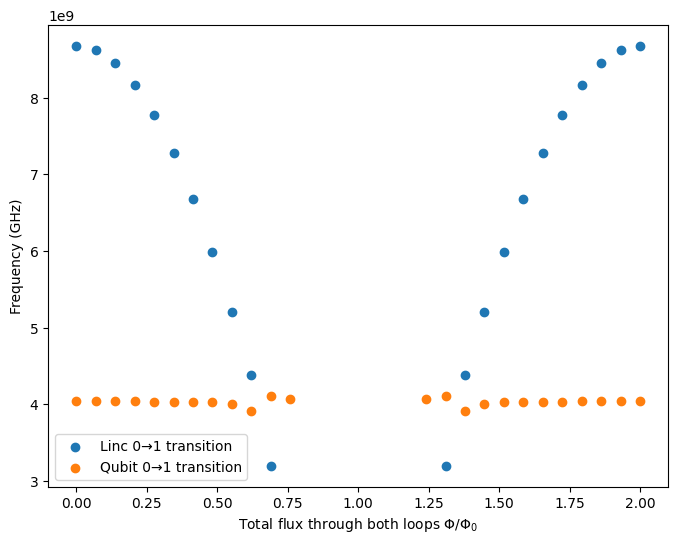

In [8]:
linc_frequency = []
flux_values_linc = []
for i, flux in enumerate(flux_values):
    if evals_sorted_flux[i][1][0] is not None and evals_sorted_flux[i][0][0] is not None:
        linc_frequency.append(evals_sorted_flux[i][1][0] - evals_sorted_flux[i][0][0])  # first excited linc state minus ground state with qubit in ground state 
        flux_values_linc.append([flux_values[i]])

qubit_frequency = []
flux_values_qubit = []
for i, flux in enumerate(flux_values):
    if evals_sorted_flux[i][0][1] is not None and evals_sorted_flux[i][0][0] is not None:
        qubit_frequency.append(evals_sorted_flux[i][0][1] - evals_sorted_flux[i][0][0])  # first excited qubit state minus ground state with linc in ground state 
        flux_values_qubit.append([flux_values[i]])

plt.figure(figsize=(8,6))
plt.scatter(flux_values_linc, linc_frequency, label='Linc 0→1 transition')
plt.scatter(flux_values_qubit, qubit_frequency, label='Qubit 0→1 transition')
plt.xlabel(r'Total flux through both loops $\Phi/\Phi_0$')
plt.ylabel('Frequency (GHz)')
plt.legend()
plt.show()


In [9]:
print(E_l/h / 1e9)  # print linc frequency in GHz

46.70328940807682
